# TP03 - CLASIFICANDO DE POBRES CON LA EPH – [Taller de Programación]
## Alumnos:  Kostzer Federico - Meza Palma Manuel Humberto - Pardini Maximiliano Gabriel - 
## Fecha: 15/11/2025

A. Enfoque de validación 

Utilicen la base respondieron. Para cada año, dividan las observaciones en una base de prueba (test) y una de entrenamiento (train) utilizando el comando train_test_split. La base de entrenamiento debe comprender el 70% de los datos, y la semilla a utilizar (random state instance) debe ser 444. Establezca a pobre como su variable dependiente en la base de entrenamiento (vector y). El resto de las variables seleccionadas serán las variables independientes (matriz X). Recuerden agregar la columna de unos (1) para el intercepto. Aclaración: no incluir la variable ingreso en X para predecir la pobreza porque cuando vayamos a la base de norespondieron no vamos a tener esa información. 


1.	 Cree una tabla de diferencia de medias entre la base de entrenamiento y la de testeo de las características seleccionadas en su matriz X. Para la matriz de las X seleccione variables que hayan limpiado en los TPs anteriores y justifique su inclusión para predecir la pobreza. Comente la tabla de la diferencia de medias de sus variables entre entrenamiento y testeo. ¿Hay diferencias significativas entre las medias del entrenamiento y testeo? 

In [1]:
# %% ------------------------------------
# 📦 Configuración inicial
# %% ------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import os
print(os.getcwd())
import statsmodels.api as sm  
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score




sns.set(style="whitegrid")

c:\Users\User\OneDrive\Documentos\GitHub\Big-Data-UBA--Grupo-3\TP03


In [14]:
## Configuracion de ruta y base de datos

# Detectar automáticamente la raíz del repositorio (carpeta que contiene .git)
# Si tu notebook está dentro de una o más subcarpetas, este código igual funcionará
RUTA_REPO = Path.cwd()
while not (RUTA_REPO / ".git").exists() and RUTA_REPO != RUTA_REPO.parent:
    RUTA_REPO = RUTA_REPO.parent

# Definir la ruta base (por ejemplo, carpeta BASES dentro del repo)
RUTA_BASE = RUTA_REPO / "TP03"

print(f"📁 Raíz del repositorio: {RUTA_REPO}")
print(f"📂 Carpeta de bases: {RUTA_BASE}")
 

📁 Raíz del repositorio: c:\Users\User\OneDrive\Documentos\GitHub\Big-Data-UBA--Grupo-3
📂 Carpeta de bases: c:\Users\User\OneDrive\Documentos\GitHub\Big-Data-UBA--Grupo-3\TP03


In [25]:


# ==============================
# 1️⃣ Cargar base respondieron
# ==============================
respondieron_ruta = os.path.join(RUTA_BASE, "respondieron.csv")
respondieron = pd.read_csv(respondieron_ruta, encoding="utf-8", low_memory=False)
respondieron.columns = respondieron.columns.str.strip()  # limpiar espacios


# Normalizar nombres de columnas (minúsculas y sin espacios)
respondieron.columns = respondieron.columns.str.strip().str.lower()

# ==============================
# 2️⃣ Variables seleccionadas
# ==============================
vars_pred = ['ch04', 'ch06', 'ch07', 'nivel_ed', 'estado', 'ch03', 'ch09', 'ch10', 'pp3e_tot']

# ==============================
# 3️⃣ Crear DataFrame de modelo
# ==============================
df_modelo = respondieron[vars_pred + ['pobre']].copy()

# ==============================
# 4️⃣ Imputar NAs con mediana para numéricas
# ==============================
num_cols = ['ch06', 'ch07', 'estado', 'ch09', 'ch10', 'pp3e_tot']  # columnas numéricas
for col in num_cols:
    med = df_modelo[col].median()
    df_modelo[col] = df_modelo[col].fillna(med)

# ==============================
# 5️⃣ Convertir categóricas a dummies
# ==============================
cat_cols = ['ch04','nivel_ed']  # columnas categóricas
df_modelo = pd.get_dummies(df_modelo, columns=cat_cols, drop_first=True)

# ==============================
# 6️⃣ Separar X e y
# ==============================
X = df_modelo.drop(columns='pobre')
y = df_modelo['pobre']

# ==============================
# 7️⃣ Agregar columna de unos (intercepto)
# ==============================
X = X.assign(intercepto=1)

# ==============================
# 8️⃣ Dividir en train y test (70/30)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=444
)

# ==============================
# 9️⃣ Diferencia de medias 
# ==============================
mean_train = X_train.mean()
mean_test  = X_test.mean()

diff_means = pd.DataFrame({
    'Media_Train': mean_train,
    'Media_Test': mean_test,
    'Dif_Media': mean_train - mean_test
})
diff_means['Abs_Dif'] = diff_means['Dif_Media'].abs()
diff_means_sorted = diff_means.sort_values(by='Abs_Dif', ascending=False)

print("📊 Diferencia de medias entre Train y Test:")
display(diff_means_sorted.head(20))


📊 Diferencia de medias entre Train y Test:


,Media_Train,Media_Test,Dif_Media,Abs_Dif
ch06,34.123825,33.961401,0.162425,0.162425
pp3e_tot,14.921606,14.825511,0.096096,0.096096
estado,2.295923,2.311088,-0.015165,0.015165
ch04_2,0.519634,0.526511,-0.006877,0.006877
ch10,1.719834,1.713172,0.006662,0.006662
ch07,3.574731,3.580117,-0.005386,0.005386
nivel_ed_3,0.190964,0.193997,-0.003034,0.003034
nivel_ed_6,0.108157,0.105169,0.002989,0.002989
ch03,2.511184,2.508295,0.002889,0.002889
nivel_ed_4,0.171598,0.168862,0.002736,0.002736


In [16]:
na_counts = respondieron[vars_pred + ['pobre']].isna().sum()
print(na_counts)


ch04            0
ch06          935
ch07            5
nivel_ed        0
estado         58
ch03            0
ch09            6
ch10         1954
pp3e_tot    19089
pobre           0
dtype: int64


2. Separen la base respondieron en dos: respondieron_2005 y respondieron_2025. Idem con la base norespondieron.

In [17]:
# ==============================
# Separar por año
# ==============================
respondieron_2005 = respondieron[respondieron['ano4'] == 2005].copy()
respondieron_2025 = respondieron[respondieron['ano4'] == 2025].copy()

# Verificar cantidad de filas por año
print("Cantidad de registros 2005:", len(respondieron_2005))
print("Cantidad de registros 2025:", len(respondieron_2025))


Cantidad de registros 2005: 46592
Cantidad de registros 2025: 33372


In [18]:
# ==============================
# 1️⃣ Cargar base norespondieron
# ==============================
ruta_norespondieron = r"..\TP01\norespondieron.csv"
norespondieron = pd.read_csv(ruta_norespondieron, low_memory=False)

# Limpiar espacios en nombres de columnas
norespondieron.columns = norespondieron.columns.str.strip()

# Verificar primer vistazo
print(norespondieron.head())
print(f"Cantidad total de registros: {len(norespondieron)}")

norespondieron_2005 = norespondieron[norespondieron['ano4']==2005].copy()
norespondieron_2025 = norespondieron[norespondieron['ano4']==2025].copy()

print(f"Cantidad de registros 2005: {len(norespondieron_2005)}")
print(f"Cantidad de registros 2025: {len(norespondieron_2025)}")



     codusu  nro_hogar componente  h15    ano4       trimestre  region  \
0  155508          1.0        1.0   Sí  2005.0  1er. Trimestre       1   
1  155508          1.0        2.0   Sí  2005.0  1er. Trimestre       1   
2  155508          1.0        3.0   Sí  2005.0  1er. Trimestre       1   
3  155508          1.0        4.0  0.0  2005.0  1er. Trimestre       1   
4  160429          1.0        1.0   Sí  2005.0  1er. Trimestre       1   

  mas_500  aglomerado  pondera  ...  v22_02_m  v22_03_m  p_deccf  p_rdeccf  \
0       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
1       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
2       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
3       S         NaN   1401.0  ...       NaN       NaN      NaN       NaN   
4       S         NaN   1202.0  ...       NaN       NaN      NaN       NaN   

   p_gdeccf  p_pdeccf  p_ideccf p_adeccf    anio   sexo  
0       NaN       NaN       

B. Modelo de Regresion Logística 

3.	Estimación y Efectos Marginales: Estimen una Regresión Logística usando X_train de respondieron_2025. Exporten una tabla con: (i) los coeficientes estimados para cada variable, (ii) los errores estándar y (ii) los odd-ratios. Interpreten los resultados de la tabla. (Hint: en la clase 7 hay una ilustración de la tabla).

In [19]:
# ==========================================================
# B. MODELO DE REGRESIÓN LOGÍSTICA (AÑO 2025) - DEFINITIVO
# ==========================================================

# ----------------------------------------------------------
# 1️⃣ Definir variables predictoras y dependiente
# ----------------------------------------------------------
variables_X = ['ch04', 'ch06', 'ch07', 'nivel_ed', 'estado', 'ch03', 'ch09', 'ch10', 'pp3e_tot']
y = respondieron_2025['pobre']
X = respondieron_2025[variables_X].copy()

# ----------------------------------------------------------
# 2️⃣ Convertir categóricas a dummies (drop_first=True para evitar colinealidad)
# ----------------------------------------------------------
X = pd.get_dummies(X, columns=['ch04', 'nivel_ed'], drop_first=True)

# ----------------------------------------------------------
# 3️⃣ Dividir en entrenamiento (70%) y prueba (30%)
# ----------------------------------------------------------
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X, y, test_size=0.3, random_state=444
)

# ----------------------------------------------------------
# 4️⃣ Agregar constante (intercepto)
# ----------------------------------------------------------
X_train_2025 = sm.add_constant(X_train_2025)
X_test_2025 = sm.add_constant(X_test_2025)

# ----------------------------------------------------------
# 5️⃣ Asegurar tipos numéricos y eliminar columnas problemáticas
# ----------------------------------------------------------
# Convertir todos los valores a numéricos (forzar float)
X_train_2025 = X_train_2025.apply(pd.to_numeric, errors='coerce')

# Eliminar filas con NAs creados por coerción
mask_valid = X_train_2025.notnull().all(axis=1)
X_train_2025 = X_train_2025.loc[mask_valid]
y_train_2025 = y_train_2025.loc[mask_valid]

# Eliminar columnas sin variación (constantes)
const_cols = [col for col in X_train_2025.columns if X_train_2025[col].nunique() <= 1]
if const_cols:
    print(f"⚠️ Eliminando columnas sin variabilidad: {const_cols}")
    X_train_2025 = X_train_2025.drop(columns=const_cols)

# 🔧 Volver a convertir bool → int (por seguridad)
for c in X_train_2025.select_dtypes(include=['bool']).columns:
    X_train_2025[c] = X_train_2025[c].astype(int)

# ----------------------------------------------------------
# 6️⃣ Verificación final de tipos
# ----------------------------------------------------------
print("\nTipos finales de columnas en X_train_2025:")
print(X_train_2025.dtypes)

# ----------------------------------------------------------
# 7️⃣ Estimar el modelo Logit
# ----------------------------------------------------------
logit_model = sm.Logit(y_train_2025, X_train_2025)
result = logit_model.fit()

# ----------------------------------------------------------
# 8️⃣ Crear tabla de resultados
# ----------------------------------------------------------
tabla_resultados = pd.DataFrame({
    'Coeficiente': result.params,
    'Error_Estándar': result.bse,
    'z': result.tvalues,
    'p-valor': result.pvalues,
    'Odds_Ratio': np.exp(result.params)
}).round(4)

# ----------------------------------------------------------
# 9️⃣ Mostrar resultados
# ----------------------------------------------------------
print(result.summary())
print("\nTabla resumen de coeficientes, errores estándar y odds ratios:\n")
print(tabla_resultados)


⚠️ Eliminando columnas sin variabilidad: ['const', 'estado']

Tipos finales de columnas en X_train_2025:
ch06          float64
ch07          float64
ch03            int64
ch09          float64
ch10          float64
pp3e_tot      float64
ch04_2          int64
nivel_ed_2      int64
nivel_ed_3      int64
nivel_ed_4      int64
nivel_ed_5      int64
nivel_ed_6      int64
nivel_ed_7      int64
dtype: object
Optimization terminated successfully.
         Current function value: 0.574228
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  pobre   No. Observations:                 9888
Model:                          Logit   Df Residuals:                     9875
Method:                           MLE   Df Model:                           12
Date:                Thu, 13 Nov 2025   Pseudo R-squ.:                  0.1099
Time:                        16:12:34   Log-Likelihood:                -5678.0
converged:         

In [20]:
# Ver tipos de datos
print(X_train_2025.dtypes)

# Ver si alguna variable no es numérica
no_numericas = X_train_2025.select_dtypes(exclude=['number']).columns
print("\nColumnas no numéricas en X_train_2025:")
print(no_numericas.tolist())

print("\nTipo de y_train_2025:", y_train_2025.dtype)


ch06          float64
ch07          float64
ch03            int64
ch09          float64
ch10          float64
pp3e_tot      float64
ch04_2          int64
nivel_ed_2      int64
nivel_ed_3      int64
nivel_ed_4      int64
nivel_ed_5      int64
nivel_ed_6      int64
nivel_ed_7      int64
dtype: object

Columnas no numéricas en X_train_2025:
[]

Tipo de y_train_2025: int64


4. Visualización: Grafiquen la P ̂(Y=1|X) (en el eje vertical) y alguna característica numérica (en el eje horizontal). Comente dicho gráfico y la variable seleccionada para ilustrar la probabilidad de ser pobre según la característica seleccionada. (Hint: en la clase 7 hay una ilustración de este estilo).

📊 Estadísticas descriptivas de edad:
count    9888.000000
mean       41.173341
std        12.801979
min        10.000000
25%        31.000000
50%        40.000000
75%        50.000000
max        99.000000
Name: ch06, dtype: float64

📈 Distribución de edad:
ch06
10.0    1
13.0    1
14.0    3
15.0    3
16.0    6
       ..
81.0    4
82.0    1
83.0    1
88.0    2
99.0    1
Name: count, Length: 73, dtype: int64

📉 Probabilidad promedio de pobreza por edad:
   edad  prob_pobre
0  10.0    0.791130
1  13.0    0.695976
2  14.0    0.687674
3  15.0    0.672416
4  16.0    0.618762
5  17.0    0.597986
6  18.0    0.505643
7  19.0    0.480361
8  20.0    0.465886
9  21.0    0.455382


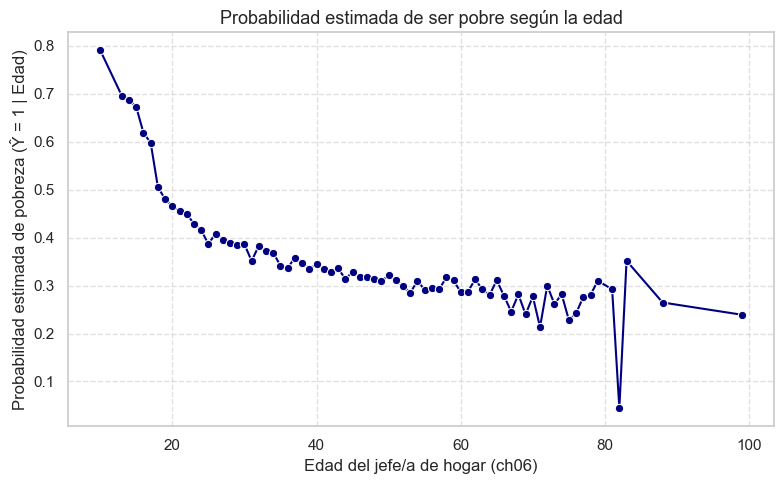

In [21]:
# ==========================================================
# ANÁLISIS DESCRIPTIVO DE LA VARIABLE EDAD Y SU RELACIÓN CON LA POBREZA
# ==========================================================

# 1️⃣ Estadísticas descriptivas básicas de edad
print("📊 Estadísticas descriptivas de edad:")
print(X_train_2025['ch06'].describe())

# 2️⃣ Distribución de frecuencia de edad
print("\n📈 Distribución de edad:")
print(X_train_2025['ch06'].value_counts().sort_index())

# ----------------------------------------------------------
# 3️⃣ Alineamos columnas con las del modelo original
# ----------------------------------------------------------
# Usamos solo las columnas que el modelo efectivamente utilizó
X_train_pred = X_train_2025[result.model.exog_names]

# ----------------------------------------------------------
# 4️⃣ Predecimos las probabilidades
# ----------------------------------------------------------
pred_probs = result.predict(X_train_pred)

# 5️⃣ Creamos un DataFrame con edad y probabilidad
df_plot = pd.DataFrame({
    'edad': X_train_2025['ch06'],
    'prob_pobre': pred_probs
})

# 6️⃣ Calculamos la probabilidad promedio de ser pobre por edad
edad_prob = df_plot.groupby('edad', as_index=False)['prob_pobre'].mean()

print("\n📉 Probabilidad promedio de pobreza por edad:")
print(edad_prob.head(10))

# 7️⃣ Graficamos la relación edad - probabilidad de pobreza
plt.figure(figsize=(8,5))
sns.lineplot(data=edad_prob, x='edad', y='prob_pobre', marker='o', color='navy')
plt.title("Probabilidad estimada de ser pobre según la edad", fontsize=13)
plt.xlabel("Edad del jefe/a de hogar (ch06)")
plt.ylabel("Probabilidad estimada de pobreza (Ŷ = 1 | Edad)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [22]:
# Contar cuántos casos hay para cada edad
conteo_edad = X_train_2025['ch06'].value_counts().sort_index()
print(conteo_edad.tail(10))  # ver las edades más altas


ch06
75.0    11
76.0     8
77.0     8
78.0     7
79.0     9
81.0     4
82.0     1
83.0     1
88.0     2
99.0     1
Name: count, dtype: int64


## C. Método de Vecinos Cercanos (KNN)

5.	Estimación: Clasifiquen a las observaciones como “pobre”/“no pobre” en su región con Vecinos Cercanos (KNN) usando  K={1,5,10} para su matriz X_train de respondieron_2025. Expliquen en no más de 2-3 oraciones cómo la elección de K se relaciona con el trade-off sesgo varianza.  

In [23]:
# Veamos la dimension de los vectores creados
print(X_train_2025.shape, X_test_2025.shape, y_train_2025.shape, y_test_2025.shape)

X_train_2025


(9888, 13) (10012, 15) (9888,) (10012,)


,ch06,ch07,ch03,ch09,ch10,pp3e_tot,ch04_2,nivel_ed_2,nivel_ed_3,nivel_ed_4,nivel_ed_5,nivel_ed_6,nivel_ed_7
57751,25.0,5.0,1,1.0,2.0,45.0,1,0,0,1,0,0,0
75259,34.0,1.0,1,1.0,2.0,24.0,0,0,1,0,0,0,0
62217,36.0,2.0,2,1.0,2.0,4.0,1,0,0,1,0,0,0
76574,29.0,5.0,3,1.0,2.0,45.0,0,0,0,1,0,0,0
63532,39.0,5.0,1,1.0,2.0,0.0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76236,62.0,1.0,2,1.0,2.0,40.0,1,0,0,0,1,0,0
64418,56.0,5.0,3,1.0,2.0,65.0,1,0,0,1,0,0,0
74575,27.0,5.0,1,1.0,2.0,0.0,1,0,0,0,1,0,0
52207,33.0,5.0,3,1.0,2.0,66.0,0,0,0,0,1,0,0


In [13]:
X_test_2025

,const,ch06,ch07,estado,ch03,ch09,ch10,pp3e_tot,ch04_2,nivel_ed_2,nivel_ed_3,nivel_ed_4,nivel_ed_5,nivel_ed_6,nivel_ed_7
48897,1.0,62.0,1.0,1.0,2,1.0,2.0,8.0,True,False,False,True,False,False,False
58802,1.0,72.0,5.0,1.0,1,1.0,2.0,9.0,True,False,False,False,False,True,False
62164,1.0,75.0,4.0,3.0,1,1.0,2.0,NaN,True,False,False,False,False,True,False
62876,1.0,74.0,4.0,3.0,1,1.0,2.0,NaN,True,False,True,False,False,False,False
75312,1.0,21.0,1.0,3.0,4,1.0,2.0,NaN,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47441,1.0,57.0,3.0,1.0,1,1.0,2.0,56.0,False,True,False,False,False,False,False
64144,1.0,38.0,3.0,1.0,3,1.0,2.0,35.0,True,False,False,False,False,True,False
61684,1.0,67.0,5.0,3.0,1,1.0,2.0,NaN,True,False,False,False,False,False,False
59409,1.0,20.0,5.0,1.0,3,1.0,2.0,40.0,False,False,False,True,False,False,False
